In [39]:
import mysql.connector as sql
import pandas as pd
import settings as s

import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression Baseline Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
connection = sql.connect(
    host=s.DATABASE_HOSTNAME,
    user=s.ACTIVE_USERNAME,
    password=s.ACTIVE_USER_PWD,
    database=s.ACTIVE_DATABASE
)

select_query = "SELECT * FROM Kaggle.s5e8 WHERE FileCategory = 'train'"
df_train = pd.read_sql(select_query, con=connection)
connection.close()

df_train = df_train.drop('FileCategory', axis=1)
df_train.head(10)

C:\Users\bouwe\AppData\Local\Temp\ipykernel_10948\2424259142.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_train = pd.read_sql(select_query, con=connection)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0
9,9,39,management,divorced,tertiary,no,25,yes,no,cellular,8,may,119,1,-1,0,unknown,0


In [ ]:
df_train["HasPrevContact"] = (df_train["pdays"] != -1).astype(int)
df_train["default"] = df_train["default"].replace({"yes": 1, "no": 0})
df_train["housing"] = df_train["housing"].replace({"yes": 1, "no": 0})
df_train["loan"] = df_train["loan"].replace({"yes": 1, "no": 0})
df_train = df_train.drop(columns=["day", "month", "id"], axis=1)

df_train.shape

(750000, 17)

In [43]:
df_train.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y,HasPrevContact
0,0,42,technician,married,secondary,0,7,0,0,cellular,117,3,-1,0,unknown,0,0
1,1,38,blue-collar,married,secondary,0,514,0,0,unknown,185,1,-1,0,unknown,0,0
2,2,36,blue-collar,married,secondary,0,602,1,0,unknown,111,2,-1,0,unknown,0,0
3,3,27,student,single,secondary,0,34,1,0,unknown,10,2,-1,0,unknown,0,0
4,4,26,technician,married,secondary,0,889,1,0,cellular,902,1,-1,0,unknown,1,0
5,5,24,admin.,single,secondary,0,1882,1,0,cellular,1010,3,-1,0,unknown,0,0
6,6,39,blue-collar,married,secondary,0,0,0,0,telephone,90,1,-1,0,unknown,0,0
7,7,50,admin.,single,secondary,0,1595,0,0,telephone,49,25,-1,0,unknown,0,0
8,8,46,blue-collar,married,primary,0,1463,0,0,cellular,50,1,-1,0,unknown,0,0
9,9,39,management,divorced,tertiary,0,25,1,0,cellular,119,1,-1,0,unknown,0,0


In [25]:
df_RoughWork = pd.get_dummies(df_train, columns=["job", "marital", "education", "contact", "poutcome"])
df_RoughWork.head(10)

,id,age,default,balance,housing,loan,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,42,0,7,0,0,117,3,-1,0,...,True,False,False,True,False,False,False,False,False,True
1,1,38,0,514,0,0,185,1,-1,0,...,True,False,False,False,False,True,False,False,False,True
2,2,36,0,602,1,0,111,2,-1,0,...,True,False,False,False,False,True,False,False,False,True
3,3,27,0,34,1,0,10,2,-1,0,...,True,False,False,False,False,True,False,False,False,True
4,4,26,0,889,1,0,902,1,-1,0,...,True,False,False,True,False,False,False,False,False,True
5,5,24,0,1882,1,0,1010,3,-1,0,...,True,False,False,True,False,False,False,False,False,True
6,6,39,0,0,0,0,90,1,-1,0,...,True,False,False,False,True,False,False,False,False,True
7,7,50,0,1595,0,0,49,25,-1,0,...,True,False,False,False,True,False,False,False,False,True
8,8,46,0,1463,0,0,50,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
9,9,39,0,25,1,0,119,1,-1,0,...,False,True,False,True,False,False,False,False,False,True


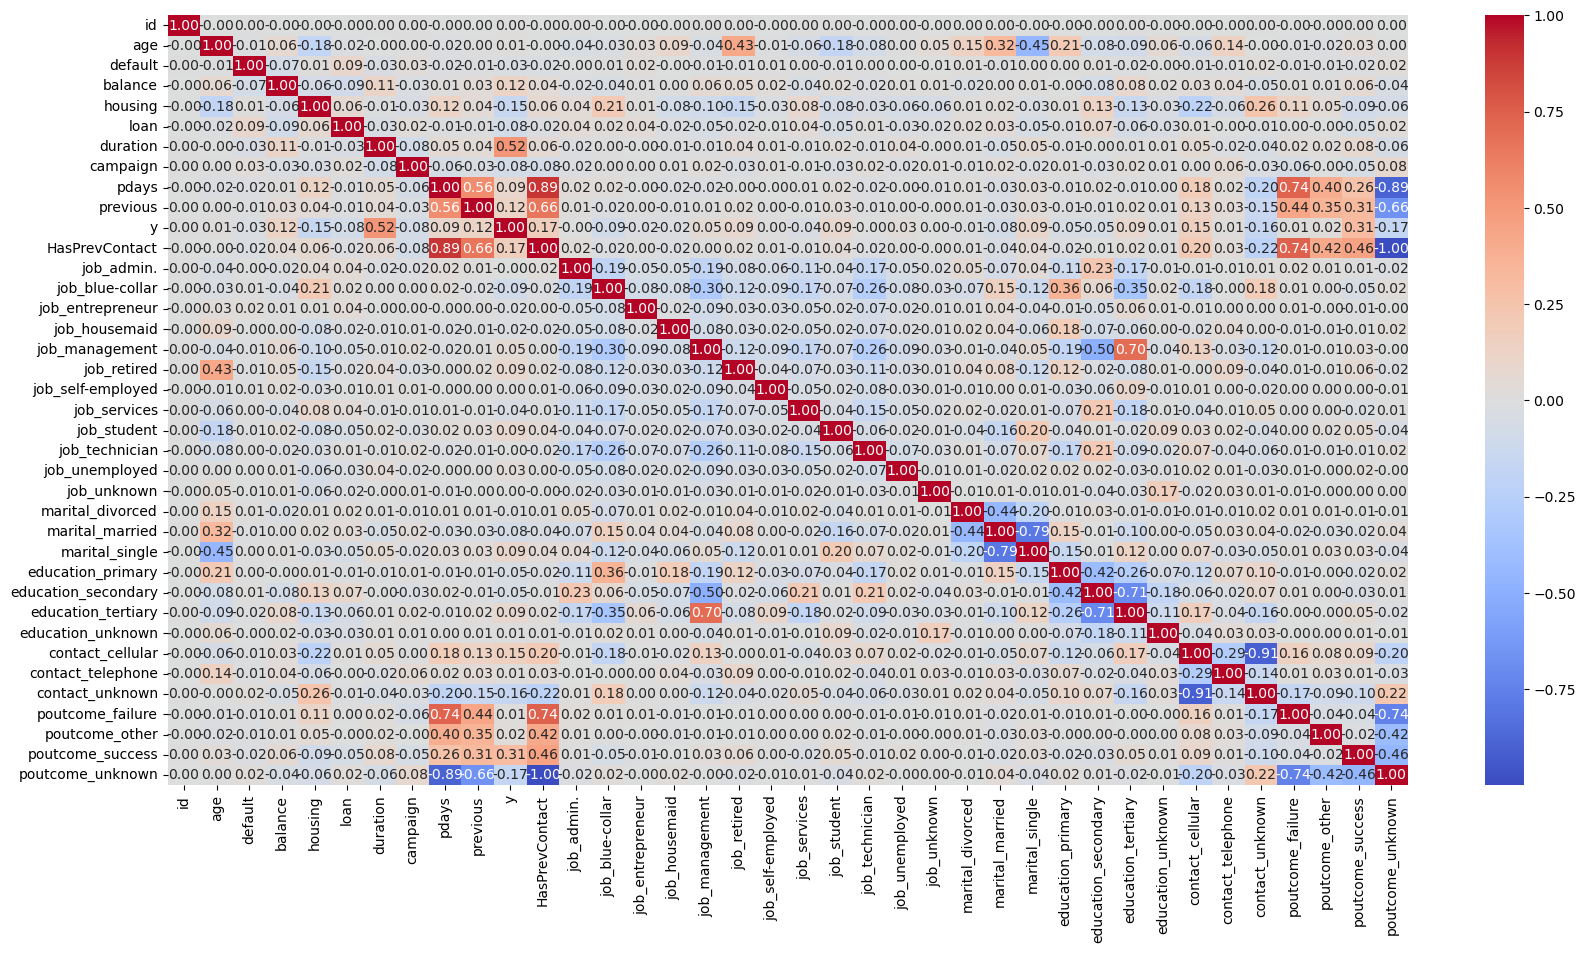

In [29]:
plt.figure(figsize=(20,10))
sns.heatmap(df_RoughWork.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [30]:
print(df_RoughWork.columns)

Index(['id', 'age', 'default', 'balance', 'housing', 'loan', 'duration',
       'campaign', 'pdays', 'previous', 'y', 'HasPrevContact', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown'],
      dtype='object')


In [31]:
# housing, balance, duration, previous, HasPrevContact
# Add: TelephonicContact, MarketingSuccess

df_RoughWork["TelephonicContact"] = ((df_RoughWork["contact_cellular"] == 1) | (df_RoughWork["contact_cellular"] == 1)).astype(int)
df_RoughWork["MarketingSuccess"] = (df_RoughWork["poutcome_success"] == 1).astype(int)

drop_columns = ['id', 'age', 'default', 'loan',
       'campaign', 'pdays',  'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown']
df_RoughWork = df_RoughWork.drop(columns=drop_columns)

df_RoughWork.head(10)

,balance,housing,duration,previous,y,HasPrevContact,TelephonicContact,MarketingSuccess
0,7,0,117,0,0,0,1,0
1,514,0,185,0,0,0,0,0
2,602,1,111,0,0,0,0,0
3,34,1,10,0,0,0,0,0
4,889,1,902,0,1,0,1,0
5,1882,1,1010,0,0,0,1,0
6,0,0,90,0,0,0,0,0
7,1595,0,49,0,0,0,0,0
8,1463,0,50,0,0,0,1,0
9,25,1,119,0,0,0,1,0


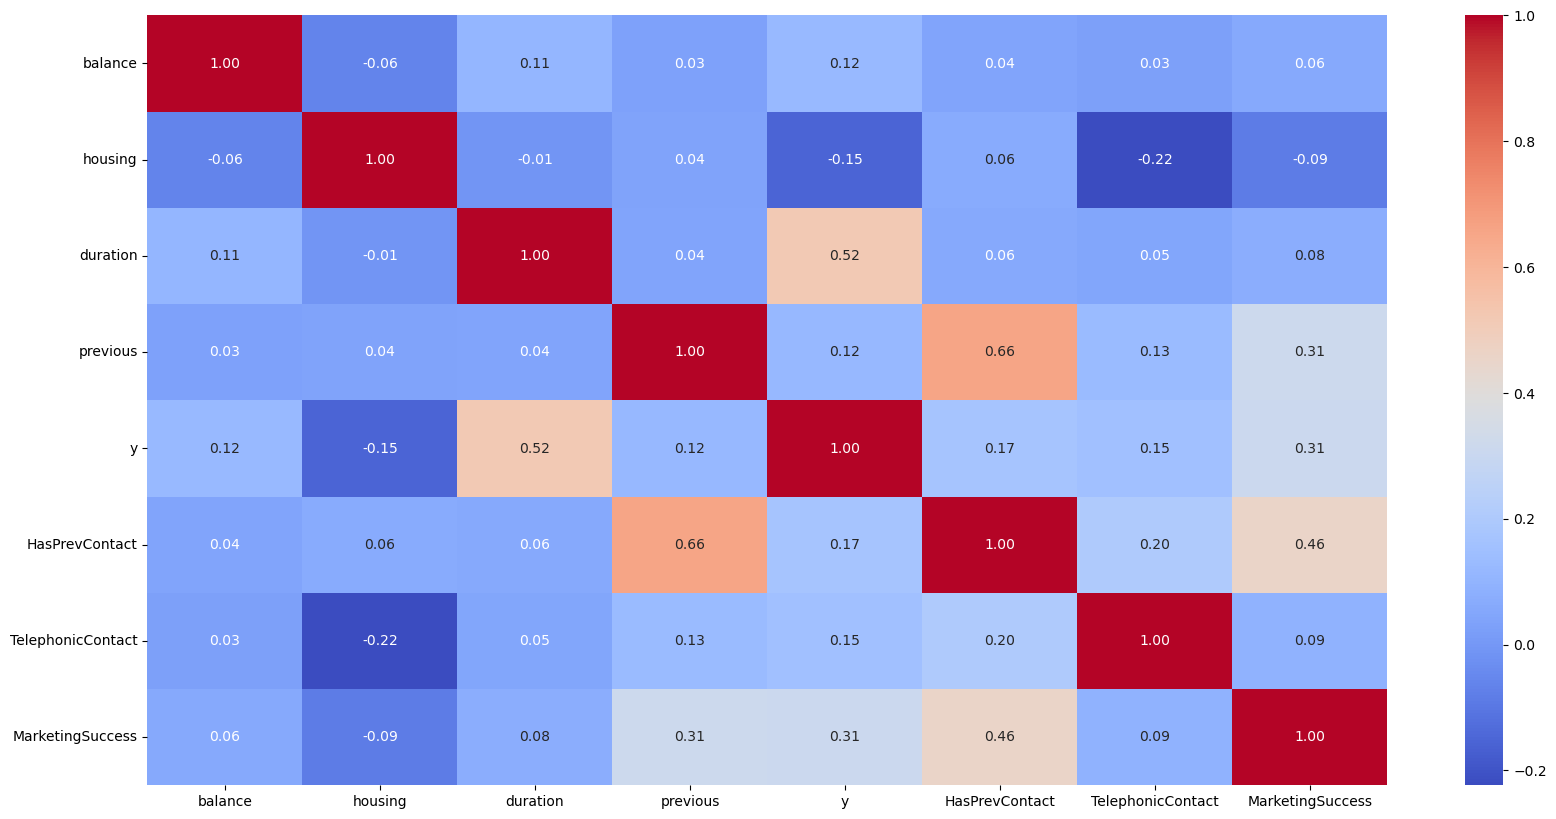

In [32]:
plt.figure(figsize=(20,10))
sns.heatmap(df_RoughWork.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [45]:
X = df_RoughWork.drop(columns=["y"], axis=1)
y = df_RoughWork["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()# class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


d:\PythonInstallation\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9078333333333334

Confusion Matrix:
 [[128378   3417]
 [ 10408   7797]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95    131795
           1       0.70      0.43      0.53     18205

    accuracy                           0.91    150000
   macro avg       0.81      0.70      0.74    150000
weighted avg       0.90      0.91      0.90    150000



In [44]:
df_LR_Prediction = pd.DataFrame({
    "Prediction": y_pred
})

df_LR_Prediction.head(10)

,Prediction
0,0
1,1
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0
